0. invstigate data
    - show data info
    - count duplicate 
    - check unique value
    - invesitage outliter
    - describe date: 各个属性的分布，不同性别下 属性之间的关系。各个属性和肥胖指数的关系。
        - bar
        - scatter
        - line
        - pie
        - box
        - heat 
        - violin

    

1. merge data
    - map join

2. clear data
    - drop duplicates
    - remove empty lines
    - remove unnecessary columns, fix column name
    - transfer data type 
    - drop outliers

3. analysis the reason for obesity


### 数据集字段说明

| 字段 | 说明 |
| --- | --- |
| Gender | 性别 |
| Age | 年龄 |
| Height | 身高 |
| Weight | 体重 |
| family_history_with_overweight | 家族肥胖史 |
| FAVC | 是否频繁食用高热量食物 |
| FCVC | 食用蔬菜的频次 |
| NCP | 食用主餐的次数 |
| CAEC | 两餐之间的食品消费：always（总是）；frequently（经常）；sometimes（有时候） |
| SMOKE | 是否吸烟 |
| CH2O | 每日耗水量 |
| SCC | 高热量饮料消耗量 |
| FAF | 运动频率 |
| TUE | 使用电子设备的时间 |
| CALC | 酒精消耗量：0（无）；frequently（经常）；sometimes（有时候） |
| MTRANS | 日常交通方式：Automobile（汽车）；Bike（自行车）；Motorbike（摩托车）；Public Transportation（公共交通）；Walking（步行） |
| Obesity_level | 肥胖水平 |

### 肥胖水平分类

| 字段 | 说明 |
| --- | --- |
| Normal_Weight | 正常 |
| Insufficient_Weight | 体重不足 |
| Obesity_Type_I | 肥胖类型 I |
| Obesity_Type_II | 肥胖类型 II |
| Obesity_Type_III | 肥胖类型 III |
| Overweight_Level_I | 一级超重 |
| Overweight_Level_II | 二级超重 |


### data description

| Field                             | Description                                                                         |
| --------------------------------- | ----------------------------------------------------------------------------------- |
| Gender                            | Gender                                                                              |
| Age                               | Age                                                                                 |
| Height                            | Height                                                                              |
| Weight                            | Weight                                                                              |
| family\_history\_with\_overweight | Family history of overweight                                                        |
| FAVC                              | Frequency of high-calorie food consumption                                          |
| FCVC                              | Frequency of vegetable consumption                                                  |
| NCP                               | Number of main meals per day                                                        |
| CAEC                              | Food consumption between meals: always; frequently; sometimes                       |
| SMOKE                             | Smoking status                                                                      |
| CH2O                              | Daily water intake                                                                  |
| SCC                               | Consumption of high-calorie beverages                                               |
| FAF                               | Frequency of physical activity                                                      |
| TUE                               | Time spent using electronic devices                                                 |
| CALC                              | Alcohol consumption: 0 (none); frequently; sometimes                                |
| MTRANS                            | Mode of transportation: Automobile; Bike; Motorbike; Public Transportation; Walking |
| Obesity\_level                    | Level of obesity                                                                    |

### Obesity\_level

| Field                 | Description         |
| --------------------- | ------------------- |
| Normal\_Weight        | Normal weight       |
| Insufficient\_Weight  | Underweight         |
| Obesity\_Type\_I      | Obesity Type I      |
| Obesity\_Type\_II     | Obesity Type II     |
| Obesity\_Type\_III    | Obesity Type III    |
| Overweight\_Level\_I  | Overweight Level I  |
| Overweight\_Level\_II | Overweight Level II |



## Initialize pyspark

In [121]:
#import libraries
from pyspark import SparkConf
from pyspark import SparkContext
from pyspark.sql import SparkSession
# set processors
master = "local[*]"
app_name = "data_integration"
spark_conf = SparkConf()\
            .setMaster(master)\
            .setAppName(app_name)\

spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()
sc = spark.sparkContext
sc.setLogLevel('ERROR')

ConnectionRefusedError: [Errno 61] Connection refused

In [2]:
# import sql functions
from pyspark.sql.functions import count, when, isnan, col, approx_count_distinct

In [3]:
sc

<SparkContext master=local[*] appName=data_integration>

## presentation config

In [4]:
# spark presentation config
# spark.conf.set("spark.sql.repl.eagerEval.maxNumRows", 100)  # max rows to display
# spark.conf.set("spark.sql.repl.eagerEval.truncate", 0)  # max width of column, 0 means no limit

# from IPython.display import display, HTML
# width in Jupyter Notebook 
# display(HTML("<style>.container { width:100% !important; }</style>"))

## Read Data

In [5]:
attribute_origin_df = spark.read.csv("obesity_level_attribute.csv", header=True, inferSchema=True)
result_origin_df = spark.read.csv("obesity_level_result.csv", header=True, inferSchema=True)


## Data Investigation

In [6]:
attribute_origin_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- Height: double (nullable = true)
 |-- Weight: double (nullable = true)
 |-- family_history_with_overweight: integer (nullable = true)
 |-- FAVC: integer (nullable = true)
 |-- FCVC: double (nullable = true)
 |-- NCP: double (nullable = true)
 |-- CAEC: string (nullable = true)
 |-- SMOKE: integer (nullable = true)
 |-- CH2O: double (nullable = true)
 |-- SCC: integer (nullable = true)
 |-- FAF: double (nullable = true)
 |-- TUE: double (nullable = true)
 |-- CALC: string (nullable = true)
 |-- MTRANS: string (nullable = true)



In [7]:
result_origin_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- 0be1dad: string (nullable = true)



In [8]:
attribute_origin_df.show(5)

+------+------+---------+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+
|    id|Gender|      Age|  Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|TUE|     CALC|              MTRANS|
+------+------+---------+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+
|678333|  Male|     33.0|    1.67|  75.0|                             0|   1| 2.0|3.0| Sometimes|    0|     2.0|  0|     1.0|0.0|Sometimes|          Automobile|
|648332|Female|     18.0|    1.58|  39.0|                             0|   1| 2.8|3.0| Sometimes|    0|     2.0|  0|     2.0|1.0|Sometimes|Public_Transporta...|
|495333|Female|19.773303|1.602082|  45.0|                             0|   0| 3.0|3.0|Frequently|    0|2.875583|  1|1.269169|0.0|Sometimes|Public_Transporta...|
|155635|Female|     22.0|    1.71|

In [9]:
result_origin_df.show(5)

+------+-------------------+
|    id|            0be1dad|
+------+-------------------+
|678333| Overweight_Level_I|
|648332|Insufficient_Weight|
|495333|Insufficient_Weight|
|155635| Overweight_Level_I|
|909431|Insufficient_Weight|
+------+-------------------+
only showing top 5 rows



**observation**: 
1. column data type match with the actual data
2. **TODO**: result_origin_df column name is incorrect, need to be fixed

In [10]:
# fix column names
result_origin_df = result_origin_df.withColumnRenamed("0be1dad", "obesity_level")


In [11]:
result_origin_df.show(5)

+------+-------------------+
|    id|      obesity_level|
+------+-------------------+
|678333| Overweight_Level_I|
|648332|Insufficient_Weight|
|495333|Insufficient_Weight|
|155635| Overweight_Level_I|
|909431|Insufficient_Weight|
+------+-------------------+
only showing top 5 rows



In [12]:
# check missing values
attribute_origin_df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in attribute_origin_df.columns]).show()
result_origin_df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in result_origin_df.columns]).show()


+---+------+---+------+------+------------------------------+----+----+---+----+-----+----+---+---+---+----+------+
| id|Gender|Age|Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|CAEC|SMOKE|CH2O|SCC|FAF|TUE|CALC|MTRANS|
+---+------+---+------+------+------------------------------+----+----+---+----+-----+----+---+---+---+----+------+
|  0|     0|  0|     0|     0|                             0|   0|   0|  0|   0|    0|   0|  0|  0|  0|   0|     0|
+---+------+---+------+------+------------------------------+----+----+---+----+-----+----+---+---+---+----+------+

+---+-------------+
| id|obesity_level|
+---+-------------+
|  0|            0|
+---+-------------+



**observation**: there are no missing value in this data set 

In [13]:
# check duplicates
attribute_origin_df.groupBy(attribute_origin_df.columns).count().filter("count > 1").show()
result_origin_df.groupBy(result_origin_df.columns).count().filter("count > 1").show()


+---+------+---+------+------+------------------------------+----+----+---+----+-----+----+---+---+---+----+------+-----+
| id|Gender|Age|Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|CAEC|SMOKE|CH2O|SCC|FAF|TUE|CALC|MTRANS|count|
+---+------+---+------+------+------------------------------+----+----+---+----+-----+----+---+---+---+----+------+-----+
+---+------+---+------+------+------------------------------+----+----+---+----+-----+----+---+---+---+----+------+-----+

+---+-------------+-----+
| id|obesity_level|count|
+---+-------------+-----+
+---+-------------+-----+



In [ ]:
# values count
attribute_origin_df.select([count(when(col(c).isNotNull(), c)).alias(c) for c in attribute_origin_df.columns]).show()
result_origin_df.select([count(when(col(c).isNotNull(), c)).alias(c) for c in result_origin_df.columns]).show()

+-----+------+-----+------+------+------------------------------+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+
|   id|Gender|  Age|Height|Weight|family_history_with_overweight| FAVC| FCVC|  NCP| CAEC|SMOKE| CH2O|  SCC|  FAF|  TUE| CALC|MTRANS|
+-----+------+-----+------+------+------------------------------+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+
|20789| 20789|20789| 20789| 20789|                         20789|20789|20789|20789|20789|20789|20789|20789|20789|20789|20789| 20789|
+-----+------+-----+------+------+------------------------------+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+

+-----+-------------+
|   id|obesity_level|
+-----+-------------+
|20789|        20789|
+-----+-------------+



In [14]:
# count unique value for each attiribute
# countDistinct() vs approx_count_distinct()
attribute_origin_df_unique_counts = attribute_origin_df.agg(*[approx_count_distinct(col(c)).alias(c) for c in attribute_origin_df.columns])
attribute_origin_df_unique_counts.show()

result_origin_df_unique_counts = result_origin_df.agg(*[approx_count_distinct(col(c)).alias(c) for c in result_origin_df.columns])
result_origin_df_unique_counts.show()



+-----+------+----+------+------+------------------------------+----+----+---+----+-----+----+---+----+----+----+------+
|   id|Gender| Age|Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|CAEC|SMOKE|CH2O|SCC| FAF| TUE|CALC|MTRANS|
+-----+------+----+------+------+------------------------------+----+----+---+----+-----+----+---+----+----+----+------+
|21635|     2|1724|  1793|  2096|                             2|   2| 884|649|   4|    2|1550|  2|1420|1308|   3|     4|
+-----+------+----+------+------+------------------------------+----+----+---+----+-----+----+---+----+----+----+------+

+-----+-------------+
|   id|obesity_level|
+-----+-------------+
|21635|            7|
+-----+-------------+



In [15]:
# check unique values for obesity_level
result_origin_df_selected_cols = ['obesity_level']
for col in result_origin_df_selected_cols:
    print(f"Unique values in {col}:")
    result_origin_df.select(col).distinct().show()


Unique values in obesity_level:
+-------------------+
|      obesity_level|
+-------------------+
|   Obesity_Type_III|
| Overweight_Level_I|
|       0rmal_Weight|
|    Obesity_Type_II|
|Insufficient_Weight|
|Overweight_Level_II|
|      Normal_Weight|
|     Obesity_Type_I|
+-------------------+



In [16]:
attribute_origin_df_selected_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
for col in attribute_origin_df_selected_cols:
    print(f"Unique values in {col}:")
    attribute_origin_df.select(col).distinct().show()


Unique values in Gender:
+------+
|Gender|
+------+
|Female|
|  Male|
+------+

Unique values in family_history_with_overweight:
+------------------------------+
|family_history_with_overweight|
+------------------------------+
|                             1|
|                             0|
+------------------------------+

Unique values in FAVC:
+----+
|FAVC|
+----+
|   1|
|   0|
+----+

Unique values in CAEC:
+----------+
|      CAEC|
+----------+
| Sometimes|
|         0|
|Frequently|
|    Always|
+----------+

Unique values in SMOKE:
+-----+
|SMOKE|
+-----+
|    1|
|    0|
+-----+

Unique values in SCC:
+---+
|SCC|
+---+
|  1|
|  0|
+---+

Unique values in CALC:
+----------+
|      CALC|
+----------+
| Sometimes|
|         0|
|Frequently|
+----------+

Unique values in MTRANS:
+--------------------+
|              MTRANS|
+--------------------+
|                Bike|
|             Walking|
|          Automobile|
|           Motorbike|
|Public_Transporta...|
+--------------------+

**observation**: 

1. **TODO**: 0rmal_Weight is invalid value, should be "Normal_Weight"
2. **TODO**: 0 is invalid value in Attribute "CALC", assume it should be "none"
3. **TODO**: 0 is invalid value in Attribute "CAEC", according to "CALC", 0 should be none also



### remove or replace unexpected values 

In [18]:
# fix obesity_level
result_origin_df = result_origin_df.withColumn("obesity_level", when(result_origin_df["obesity_level"] == "0rmal_Weight", "Normal_Weight").otherwise(result_origin_df["obesity_level"]))
result_origin_df.select("obesity_level").distinct().show()

+-------------------+
|      obesity_level|
+-------------------+
|   Obesity_Type_III|
| Overweight_Level_I|
|    Obesity_Type_II|
|Insufficient_Weight|
|Overweight_Level_II|
|      Normal_Weight|
|     Obesity_Type_I|
+-------------------+



In [ ]:
# replace 0 in "CAEC" with "never"
attribute_origin_df = attribute_origin_df.withColumn("CAEC", when(attribute_origin_df["CAEC"] == "0", "None").otherwise(attribute_origin_df["CAEC"]))
attribute_origin_df.select("CAEC").distinct().show()

+----------+
|      CAEC|
+----------+
|      None|
| Sometimes|
|Frequently|
|    Always|
+----------+



In [25]:
# replace 0 in "CALC" with "never"
attribute_origin_df = attribute_origin_df.withColumn("CALC", when(attribute_origin_df["CALC"] == "0", "None").otherwise(attribute_origin_df["CALC"]))
attribute_origin_df.select("CALC").distinct().show()

+----------+
|      CALC|
+----------+
|      None|
| Sometimes|
|Frequently|
+----------+



In [27]:
# round float values to integer
attribute_origin_df = attribute_origin_df.withColumn("Age", attribute_origin_df["Age"].cast("int"))
attribute_origin_df = attribute_origin_df.withColumn("NCP", attribute_origin_df["NCP"].cast("int"))
attribute_origin_df = attribute_origin_df.withColumn("FCVC", attribute_origin_df["FCVC"].cast("int"))


In [28]:
attribute_origin_df.show(5)

+------+------+---+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+
|    id|Gender|Age|  Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|TUE|     CALC|              MTRANS|
+------+------+---+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+
|678333|  Male| 33|    1.67|  75.0|                             0|   1|   2|  3| Sometimes|    0|     2.0|  0|     1.0|0.0|Sometimes|          Automobile|
|648332|Female| 18|    1.58|  39.0|                             0|   1|   2|  3| Sometimes|    0|     2.0|  0|     2.0|1.0|Sometimes|Public_Transporta...|
|495333|Female| 19|1.602082|  45.0|                             0|   0|   3|  3|Frequently|    0|2.875583|  1|1.269169|0.0|Sometimes|Public_Transporta...|
|155635|Female| 22|    1.71|  69.0|                             0|   1

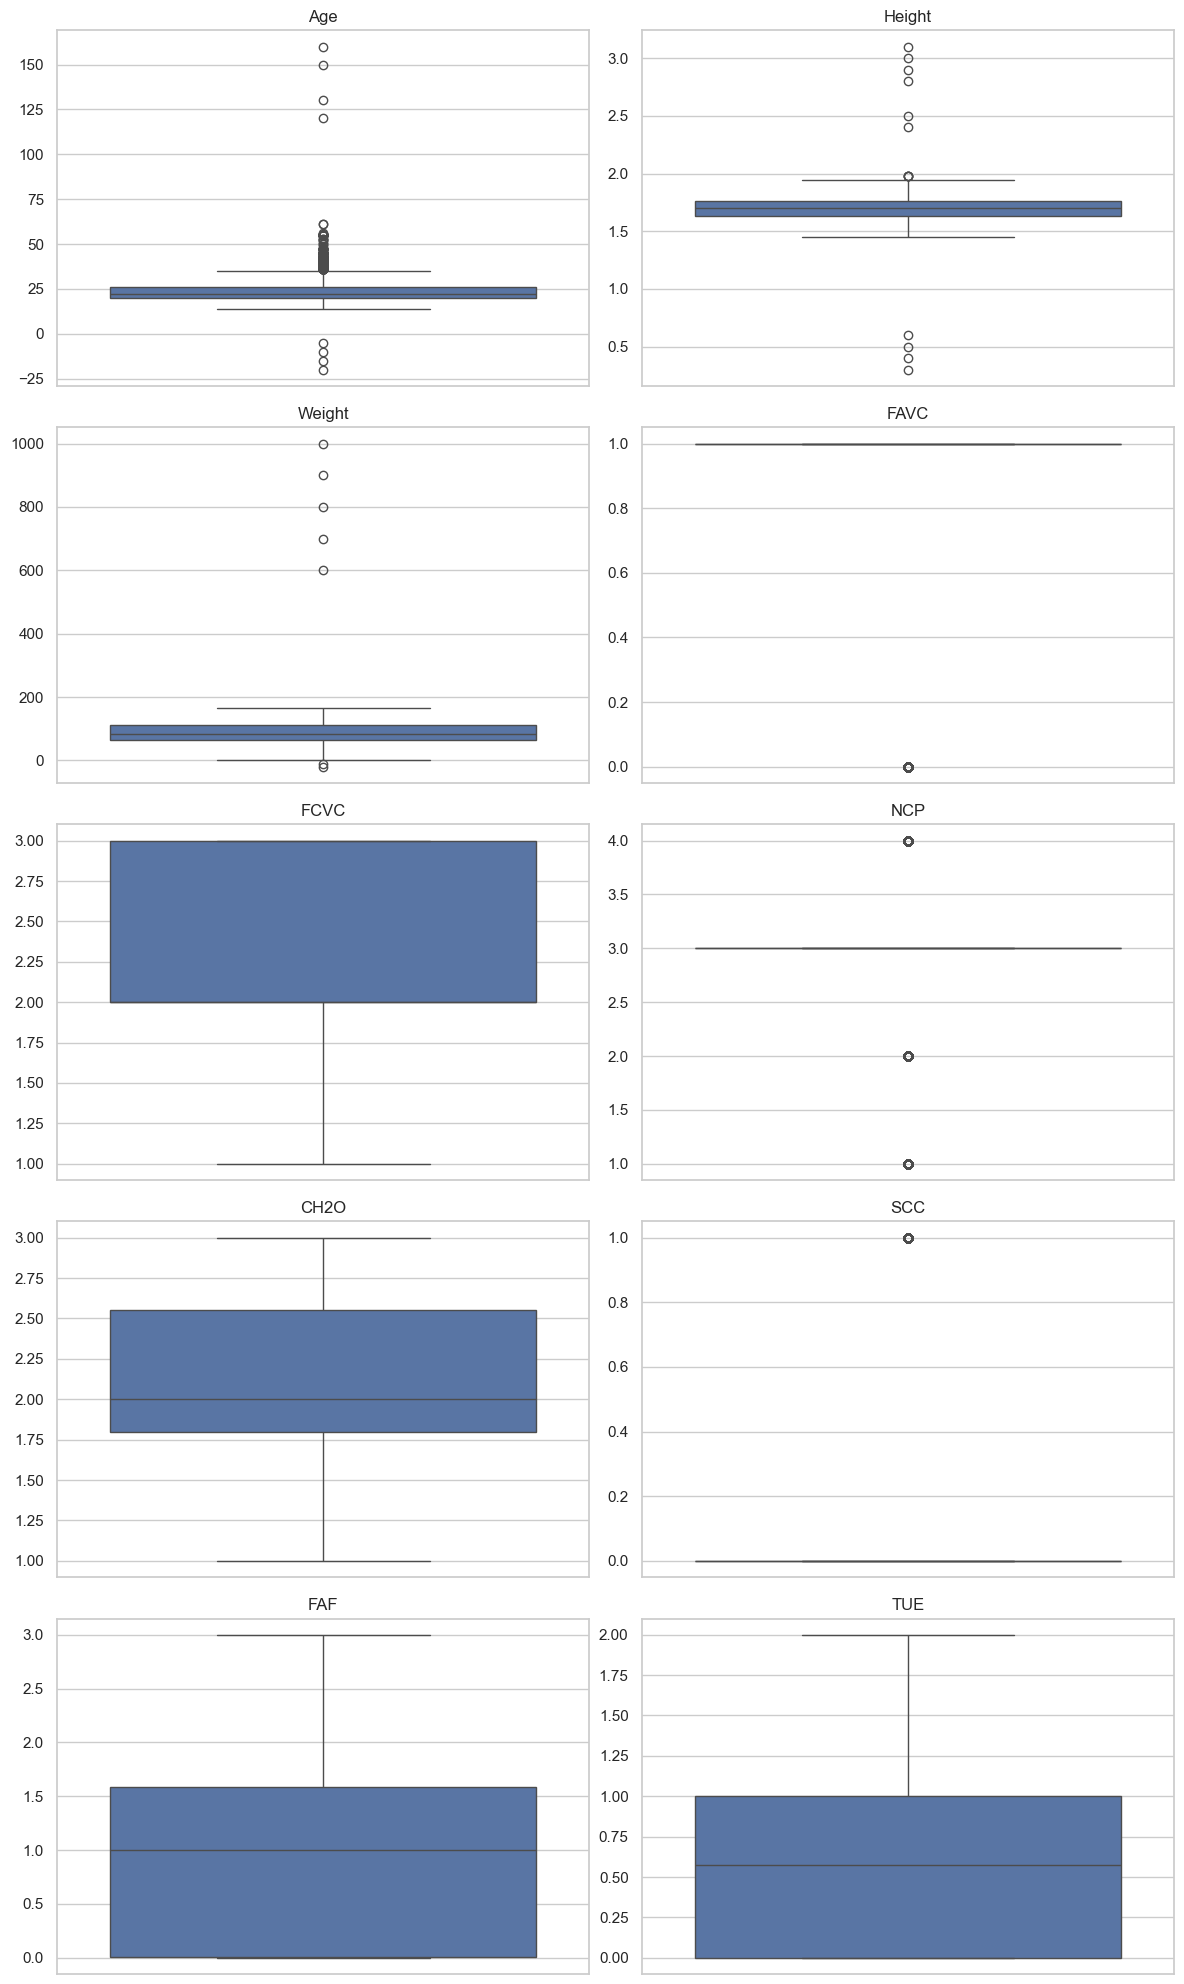

In [29]:
# find outlier

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_box(data_df):
    numeric_feature_list = ['Age', 'Height','Weight','FAVC','FCVC','NCP','CH2O','SCC','FAF','TUE']

    # transform Spark DataFrame to Pandas DataFrame
    pandas_df = data_df.select(numeric_feature_list).toPandas()

    # set the style of seaborn
    sns.set_theme(style="whitegrid")

    # create a figure with subplots
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))  
    axes = axes.flatten()  

    # loop through each feature and create a boxplot
    for i, feature in enumerate(numeric_feature_list):
        sns.boxplot(y=pandas_df[feature], ax=axes[i])  
        axes[i].set_title(feature)
        axes[i].set_ylabel('')  
    # modify the layout
    plt.tight_layout()
    plt.show()
plot_box(attribute_origin_df)

**observation**: 

1. **Age**: according to the box plot and real world, just pick up from 20 to 45
2. **Height**: according to the box plot and real world, just pick up from 1.0 to 2.0
3. **Weight**: according to the box plot and real world, just pick up from 50 to 200

In [30]:
# filter age in [0, 45]
attribute_origin_df = attribute_origin_df.filter((attribute_origin_df.Age >= 20) & (attribute_origin_df.Age <= 45))
# filter height in [1.0, 2.0]
attribute_origin_df = attribute_origin_df.filter((attribute_origin_df.Height >= 1.0) & (attribute_origin_df.Height <= 2.0))
# filter weight in [50, 200]
attribute_origin_df = attribute_origin_df.filter((attribute_origin_df.Weight >= 50) & (attribute_origin_df.Weight <= 200))


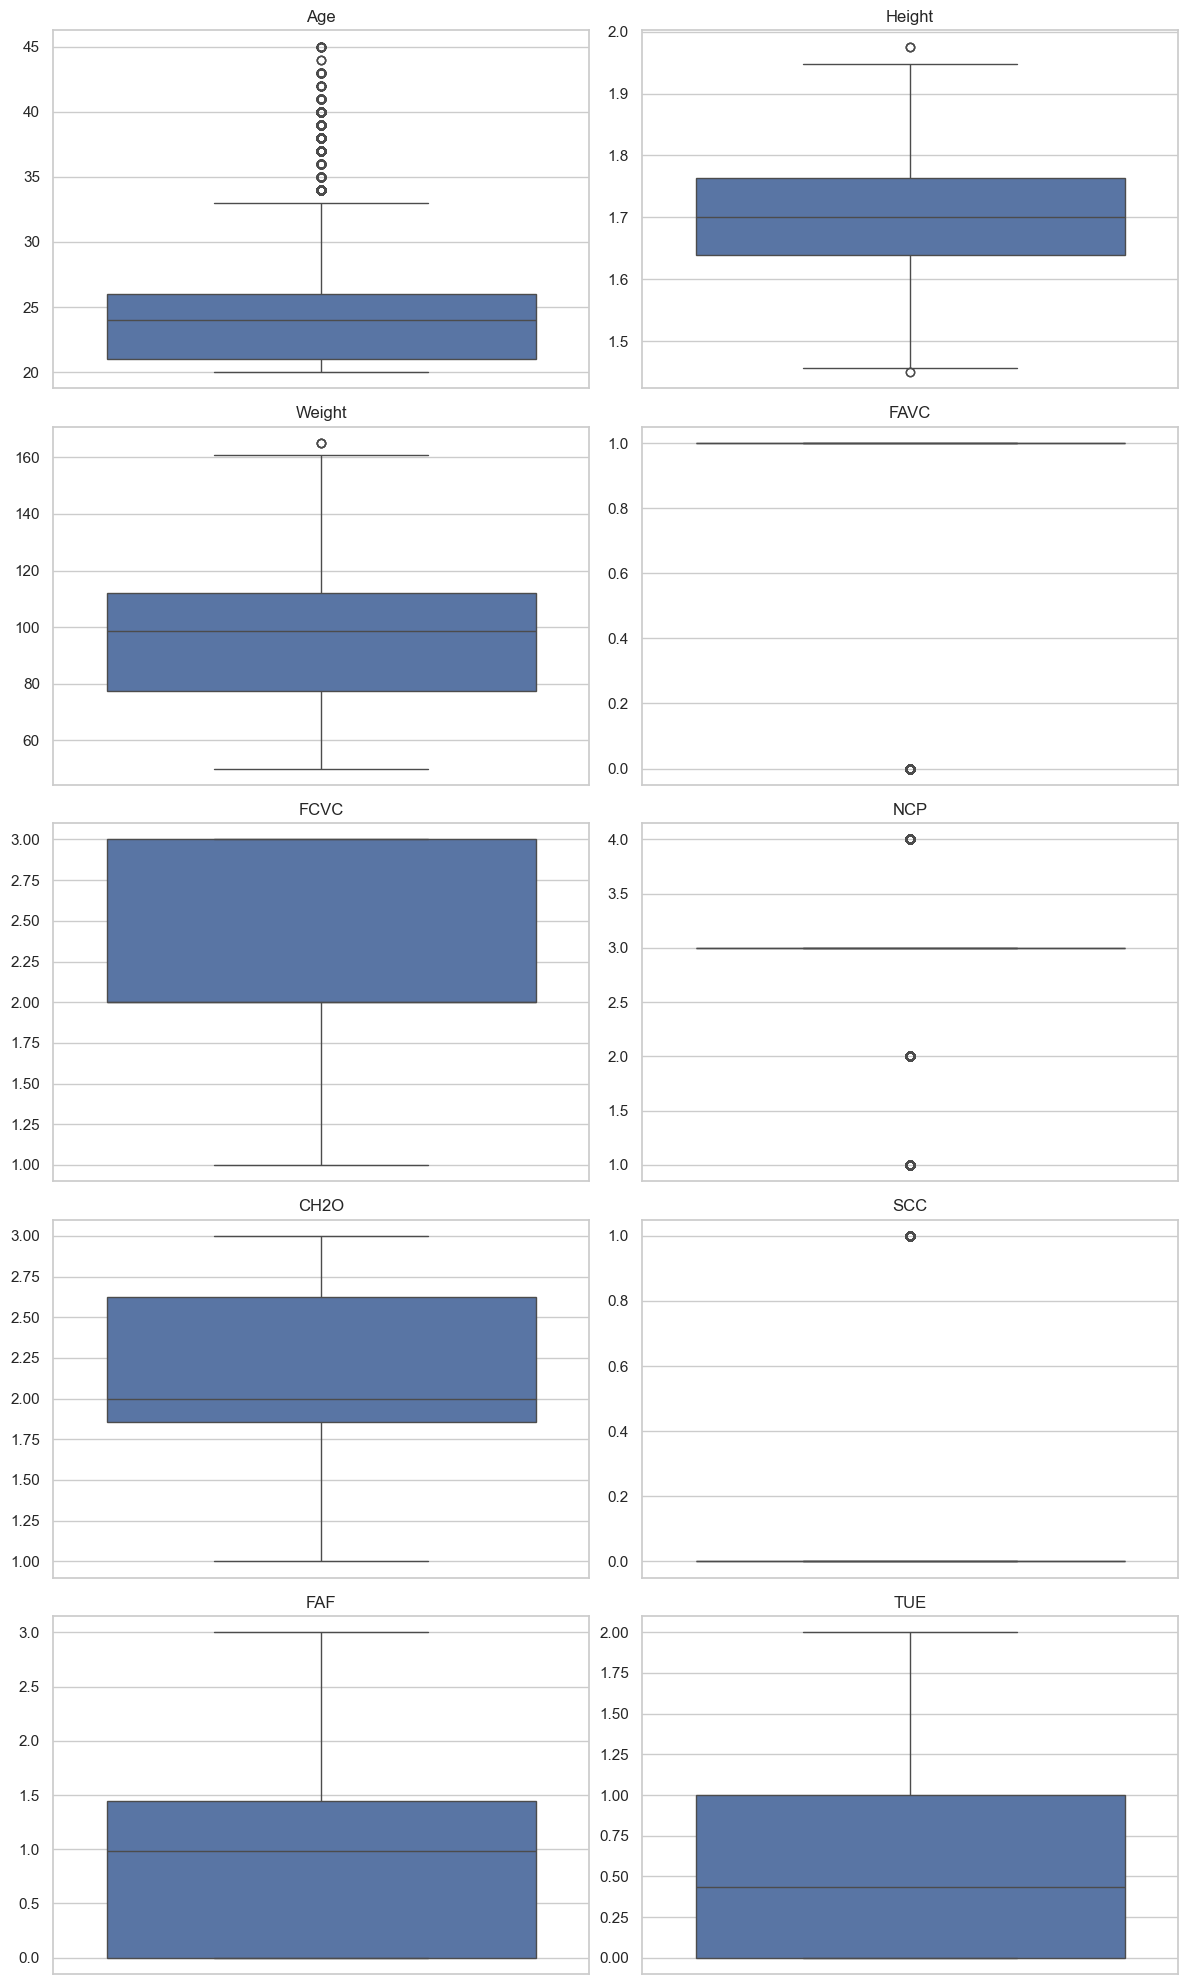

In [32]:
plot_box(attribute_origin_df)

## show the decription of the data

In [35]:
attribute_origin_df.describe().show()

+-------+------------------+------+-----------------+-------------------+------------------+------------------------------+-------------------+------------------+------------------+---------+--------------------+------------------+-------------------+------------------+------------------+----------+----------+
|summary|                id|Gender|              Age|             Height|            Weight|family_history_with_overweight|               FAVC|              FCVC|               NCP|     CAEC|               SMOKE|              CH2O|                SCC|               FAF|               TUE|      CALC|    MTRANS|
+-------+------------------+------+-----------------+-------------------+------------------+------------------------------+-------------------+------------------+------------------+---------+--------------------+------------------+-------------------+------------------+------------------+----------+----------+
|  count|             15075| 15075|            15075|           

In [36]:
attribute_origin_df.summary().show()

+-------+------------------+------+-----------------+-------------------+------------------+------------------------------+-------------------+------------------+------------------+---------+--------------------+------------------+-------------------+------------------+------------------+----------+----------+
|summary|                id|Gender|              Age|             Height|            Weight|family_history_with_overweight|               FAVC|              FCVC|               NCP|     CAEC|               SMOKE|              CH2O|                SCC|               FAF|               TUE|      CALC|    MTRANS|
+-------+------------------+------+-----------------+-------------------+------------------+------------------------------+-------------------+------------------+------------------+---------+--------------------+------------------+-------------------+------------------+------------------+----------+----------+
|  count|             15075| 15075|            15075|           

## Dataset Overview
The dataset comprises 19,527 samples, covering a range of variables related to individuals' basic information, lifestyle habits, and health indicators. The variables can be categorized into two main types: continuous variables and categorical variables.

---

## Continuous Variables

### Age
- **Range**: 14 to 61 years
- **Mean**: 23.81 years
- **Standard Deviation**: 5.69 years
- **Description**: The age distribution is relatively concentrated around 23 years, with a 25th percentile of 20 years, a median of 23 years, and a 75th percentile of 26 years. However, the maximum age of 61 years indicates some variability in the age range.

### Height
- **Range**: 1.45 meters to 1.975663 meters
- **Mean**: 1.7069 meters
- **Standard Deviation**: 0.0841 meters
- **Description**: Height is relatively consistent among the samples, with a mean of approximately 1.71 meters. The 25th percentile is 1.64 meters, the median is 1.70 meters, and the 75th percentile is 1.77 meters. However, there are some extreme values, such as the maximum height of nearly 1.98 meters.

### Weight
- **Range**: 50.0 kg to 165.057269 kg
- **Mean**: 90.62 kg
- **Standard Deviation**: 24.79 kg
- **Description**: Weight exhibits a high degree of variability, with a mean of approximately 90.6 kg. The 25th percentile is 70 kg, the median is 86.08 kg, and the 75th percentile is 111.88 kg. This suggests a wide range of weights, including both underweight and overweight individuals.

### Daily Water Intake (CH2O)
- **Range**: 1.0 liter to 3.0 liters
- **Mean**: 2.05 liters
- **Standard Deviation**: 0.60 liters
- **Description**: Daily water intake is relatively consistent, with a mean of approximately 2.05 liters. The 25th percentile is 1.87 liters, the median is 2.0 liters, and the 75th percentile is 2.57 liters.

### Weekly Exercise Frequency (FAF)
- **Range**: 0.0 times to 3.0 times
- **Mean**: 0.98 times
- **Standard Deviation**: 0.84 times
- **Description**: Weekly exercise frequency varies significantly among the samples, with a mean of approximately 1 time per week. The 25th percentile is 0 times, the median is 1 time, and the 75th percentile is 1.56 times. This indicates that a large portion of the sample exercises infrequently.

### Time Using Technological Devices (TUE)
- **Range**: 0.0 hours to 2.0 hours
- **Mean**: 0.62 hours
- **Standard Deviation**: 0.60 hours
- **Description**: Time spent using technological devices is relatively consistent, with a mean of approximately 0.62 hours. The 25th percentile is 0 hours, the median is 0.59 hours, and the 75th percentile is 1.0 hour.

---

## Categorical Variables

### Gender
- **Values**: Female, Male
- **Description**: The dataset includes both female and male samples. 

### Family History with Overweight (family_history_with_overweight)
- **Values**: 0, 1
- **Mean**: 0.86
- **Description**: Approximately 86% of the samples have a family history of overweight, indicating that a family history of overweight is quite common in this dataset.

### Frequency of High-Calorie Food Consumption (FAVC)
- **Values**: 0, 1
- **Mean**: 0.93
- **Description**: About 93% of the samples consume high-calorie foods, suggesting that high-calorie food consumption is prevalent among the samples.

### Frequency of Vegetable Consumption (FCVC)
- **Values**: 1 to 3
- **Mean**: 2.29
- **Description**: The frequency of vegetable consumption is relatively high, with a mean of approximately 2.29 times. This indicates that most samples have a regular intake of vegetables.

### Number of Main Meals (NCP)
- **Values**: 1 to 4
- **Mean**: 2.68
- **Description**: The number of main meals per day is relatively consistent, with a mean of approximately 2.68 times. This suggests that most samples have three main meals per day.

### Consumption of Snacks After Meals (CAEC)
- **Values**: Always, Never, etc.
- **Description**: The distribution of snack consumption habits can be examined through frequency counts.

### Smoking (SMOKE)
- **Values**: 0, 1
- **Mean**: 0.012
- **Description**: Only about 1.2% of the samples are smokers, indicating that smoking is relatively uncommon in this dataset.

### Consumption of Calories (SCC)
- **Values**: 0, 1
- **Mean**: 0.024
- **Description**: Only about 2.4% of the samples actively consume calories, suggesting that most samples do not engage in calorie-conscious eating.

### Mode of Transportation (MTRANS)
- **Values**: Automobile, Walking, etc.
- **Description**: The distribution of transportation modes can be examined through frequency counts.

---

## Overall Analysis
- **Continuous Variables**: The continuous variables such as age, height, weight, daily water intake, weekly exercise frequency, and time using technological devices show varying degrees of variability. Weight and exercise frequency exhibit higher variability, while height, age, and daily water intake are relatively consistent.
- **Categorical Variables**: The categorical variables such as family history of overweight, frequency of high-calorie food consumption, and vegetable consumption frequency indicate that a family history of overweight and high-calorie food consumption are common, while smoking and active calorie consumption are rare.

In [85]:
# merge data based on id
merged_df = attribute_origin_df.join(result_origin_df, on="id", how="inner")

In [86]:
merged_df.show(5)

+------+------+---+--------+---------+------------------------------+----+----+---+----------+-----+--------+---+--------+--------+----------+--------------------+-------------------+
|    id|Gender|Age|  Height|   Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|     TUE|      CALC|              MTRANS|      obesity_level|
+------+------+---+--------+---------+------------------------------+----+----+---+----------+-----+--------+---+--------+--------+----------+--------------------+-------------------+
|678333|  Male| 33|    1.67|     75.0|                             0|   1|   2|  3| Sometimes|    0|     2.0|  0|     1.0|     0.0| Sometimes|          Automobile| Overweight_Level_I|
|155635|Female| 22|    1.71|     69.0|                             0|   1|   2|  1|      None|    0|     1.0|  0|     1.0|     0.0| Sometimes|Public_Transporta...| Overweight_Level_I|
|188447|Female| 21|    1.65|     80.0|                             0|   1|   2| 

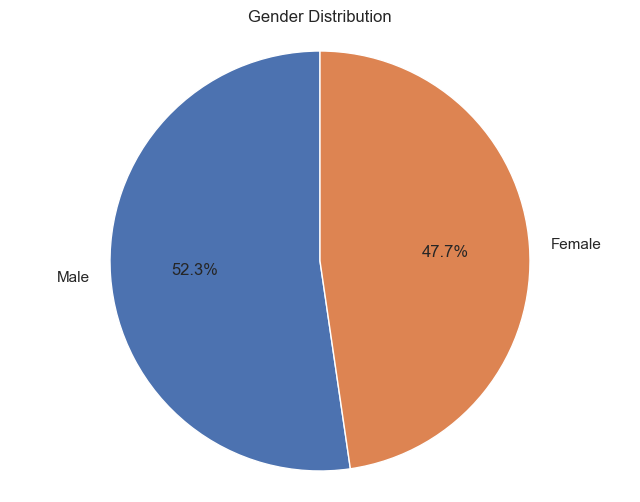

In [49]:
# 　plot gender distribution in pie chart
def plot_gender_distribution(data_df):
    # transform Spark DataFrame to Pandas DataFrame
    pandas_df = data_df.select('Gender').toPandas()
    gender_counts = pandas_df['Gender'].value_counts()

    # create a pie chart
    plt.figure(figsize=(8, 6))
    plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Gender Distribution')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

plot_gender_distribution(merged_df)


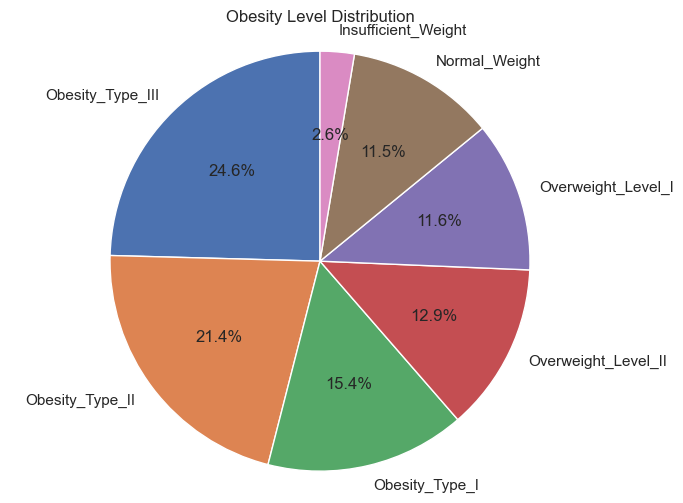

In [40]:
# the obesity level distribution
def plot_obesity_distribution(data_df):
    # transform Spark DataFrame to Pandas DataFrame
    pandas_df = data_df.select('obesity_level').toPandas()
    obesity_counts = pandas_df['obesity_level'].value_counts()

    # create a pie chart
    plt.figure(figsize=(8, 6))
    plt.pie(obesity_counts, labels=obesity_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Obesity Level Distribution')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()
plot_obesity_distribution(merged_df)

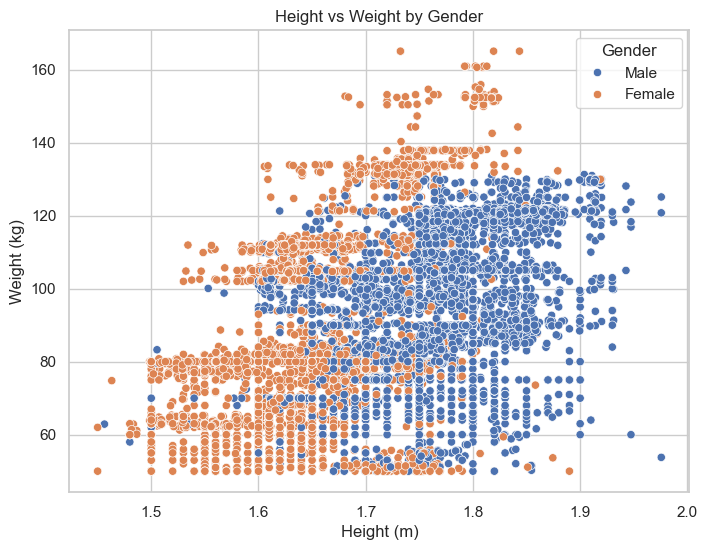

In [41]:
# the relationship between hegiht and weight in different gender
def plot_height_weight_relationship(data_df):
    # transform Spark DataFrame to Pandas DataFrame
    pandas_df = data_df.select('Height', 'Weight', 'Gender').toPandas()
    # set the style of seaborn
    sns.set_theme(style="whitegrid")
    # create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='Height', y='Weight', hue='Gender', data=pandas_df)
    plt.title('Height vs Weight by Gender')
    plt.xlabel('Height (m)')
    plt.ylabel('Weight (kg)')
    plt.show()
plot_height_weight_relationship(merged_df)

**observation**:

In this dataset, males are generally taller than females, but most individuals weighing over 140kg are female. The height and weight of males are more concentrated, while those of females are more dispersed.

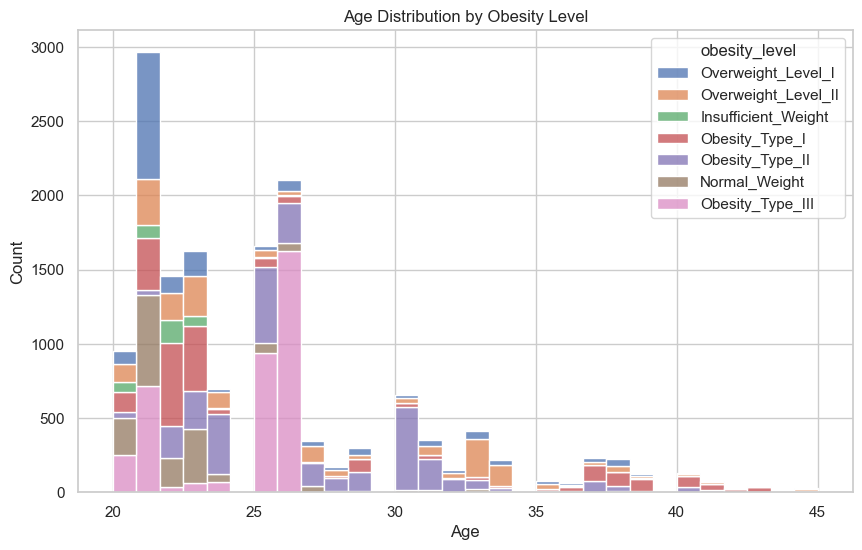

In [36]:
# plot the age count distribution, the line shows obesity level 
def plot_age_distribution(data_df):
    # transform Spark DataFrame to Pandas DataFrame
    pandas_df = data_df.select('Age', 'obesity_level').toPandas()
    
    # set the style of seaborn
    sns.set_theme(style="whitegrid")
    
    # create a histogram with a line plot
    plt.figure(figsize=(10, 6))
    sns.histplot(pandas_df, x='Age', hue='obesity_level', multiple='stack', bins=30)
    plt.title('Age Distribution by Obesity Level')
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.show()
plot_age_distribution(merged_df)

**observation**:

Most values in between 20 to 28 years old, and with the age get older, the obesity_level varity are keep decressing.



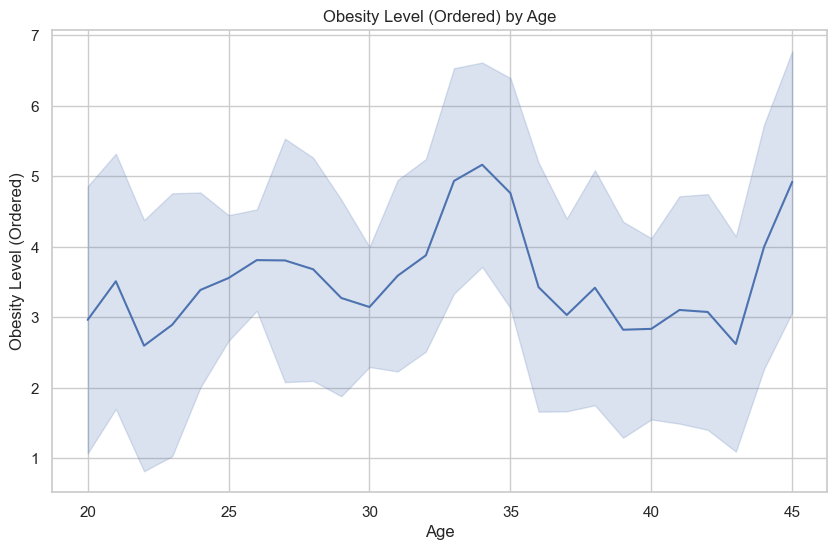

In [42]:
# Dark blue line: Represents the mean value of obesity level as age changes.
# Light blue area: Represents the uncertainty range (standard deviation) of the mean obesity level. A wider area indicates greater fluctuation (higher variance) in obesity level at that age, while a narrower area indicates less fluctuation (lower variance), meaning the data is more concentrated.

def plot_obesity_age_relationship(data_df):
    # Map obesity levels to numerical values for ordered plotting
    level_map = {
        'Overweight_Level_II': 6,
        'Overweight_Level_I': 5,
        'Obesity_Type_III': 4,
        'Obesity_Type_II': 3,
        'Obesity_Type_I': 2,
        'Normal_Weight': 1,
        'Insufficient_Weight': 0
    }
    pandas_df = data_df.select('Age', 'obesity_level').toPandas()
    pandas_df['obesity_level_num'] = pandas_df['obesity_level'].map(level_map)
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.lineplot(x='Age', y='obesity_level_num', data=pandas_df, estimator='mean', errorbar='sd')
    plt.title('Obesity Level (Ordered) by Age')
    plt.xlabel('Age')
    plt.ylabel('Obesity Level (Ordered)')
    plt.show()

plot_obesity_age_relationship(merged_df)

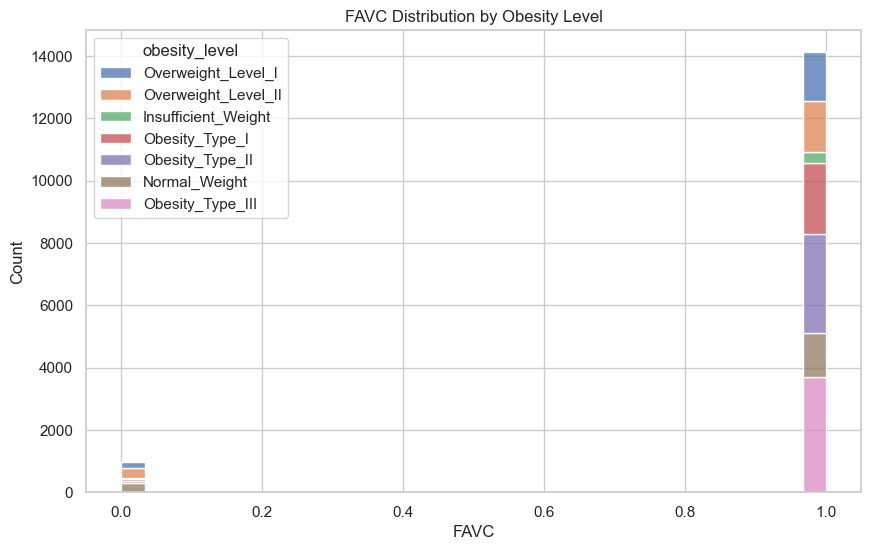

In [43]:
# plot the age count distribution, the line shows obesity level 
def plot_age_distribution(data_df):
    # transform Spark DataFrame to Pandas DataFrame
    pandas_df = data_df.select('FAVC', 'obesity_level').toPandas()
    
    # set the style of seaborn
    sns.set_theme(style="whitegrid")
    
    # create a histogram with a line plot
    plt.figure(figsize=(10, 6))
    sns.histplot(pandas_df, x='FAVC', hue='obesity_level', multiple='stack', bins=30)
    plt.title('FAVC Distribution by Obesity Level')
    plt.xlabel('FAVC')
    plt.ylabel('Count')
    plt.show()
plot_age_distribution(merged_df)

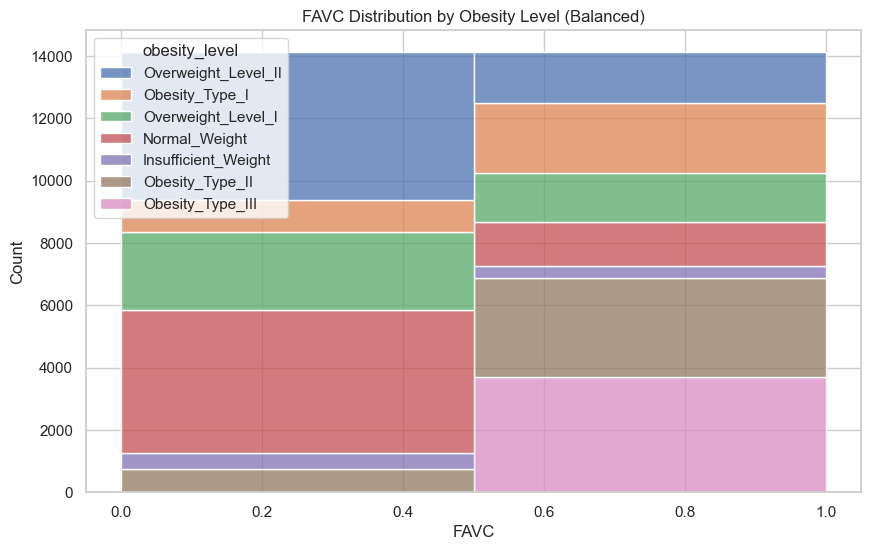

In [44]:
from sklearn.utils import resample

def plot_age_distribution(data_df):
    # transform Spark DataFrame to Pandas DataFrame
    pandas_df = data_df.select('FAVC', 'obesity_level').toPandas()
    
    # Separate the data into two groups based on FAVC
    favc_0 = pandas_df[pandas_df['FAVC'] == 0]
    favc_1 = pandas_df[pandas_df['FAVC'] == 1]
    
    # Upsample the minority class (FAVC=0)
    favc_0_upsampled = resample(favc_0, 
                                replace=True,  # sample with replacement
                                n_samples=len(favc_1),  # match the number of samples in the majority class
                                random_state=42)  # for reproducibility
    
    # Combine the upsampled minority class with the majority class
    balanced_df = pd.concat([favc_0_upsampled, favc_1])
    
    # set the style of seaborn
    sns.set_theme(style="whitegrid")
    
    # create a histogram with a line plot
    plt.figure(figsize=(10, 6))
    sns.histplot(balanced_df, x='FAVC', hue='obesity_level', multiple='stack', bins=2)
    plt.title('FAVC Distribution by Obesity Level (Balanced)')
    plt.xlabel('FAVC')
    plt.ylabel('Count')
    plt.show()

plot_age_distribution(merged_df)

In [ ]:
# transform CAEC to numerical values, Sometimes|Frequently|never|Alway
# merged_df = merged_df.withColumn("CAEC", when(merged_df["CAEC"] == "Sometimes", 1).when(merged_df["CAEC"] == "Frequently", 2).when(merged_df["CAEC"] == "None", 0).when(merged_df["CAEC"] == "Always", 3))
# merged_df = merged_df.withColumn("CALC", when(merged_df["CALC"] == "Sometimes", 1).when(merged_df["CALC"] == "Frequently", 2).when(merged_df["CALC"] == "None", 0))
# merged_df.select("CAEC").distinct().show()
# merged_df.select("CALC").distinct().show()

In [52]:
# orrelation_heatmap, this require transfer all the stirng columns to numerica column
# def plot_correlation_heatmap(data_df):
#     # transform Spark DataFrame to Pandas DataFrame
#     pandas_df = data_df.toPandas()

#     # Convert 'obesity_level' to numerical values
#     pandas_df['obesity_level'] = pandas_df['obesity_level'].map({
#         'Normal_Weight': 0,
#         'Overweight_Level_I': 1,
#         'Overweight_Level_II': 2,
#         'Obesity_Type_I': 3,
#         'Obesity_Type_II': 4,
#         'Obesity_Type_III': 5
#     })

#     # Calculate the correlation matrix
#     corr = pandas_df.corr()

#     # Set the size of the heatmap
#     plt.figure(figsize=(12, 10))

#     # Create a heatmap
#     sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})

#     plt.title('Correlation Heatmap')
#     plt.show()
# plot_correlation_heatmap(merged_df)

In [87]:
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType

obesity_level_map = {
    'Overweight_Level_II': 6,
    'Overweight_Level_I': 5,
    'Obesity_Type_III': 4,
    'Obesity_Type_II': 3,
    'Obesity_Type_I': 2,
    'Normal_Weight': 1,
    'Insufficient_Weight': 0
}

# transform obesity_level to numerical values
# define a UDF to map obesity_level to numerical values
map_obesity_level_udf = udf(lambda x: obesity_level_map.get(x), IntegerType())
merged_df= merged_df.withColumn("obesity_level", map_obesity_level_udf("obesity_level"))

In [88]:
merged_df.select("obesity_level").distinct().show()

+-------------+
|obesity_level|
+-------------+
|            1|
|            6|
|            3|
|            5|
|            4|
|            2|
|            0|
+-------------+



## Model

In [ ]:
from pyspark.ml.feature import StringIndexer,OneHotEncoder,VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier,RandomForestClassifier,GBTClassifier,NaiveBayes
from pyspark.ml import Pipeline

In [92]:
no_num_cols = ['Gender', 'family_history_with_overweight','FAVC','FCVC', 'NCP', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
num_cols = ['Age','Height','Weight','CH2O','FAF','TUE']
labels_cols = ['obesity_level']
obesity_selected_df = merged_df.select(num_cols+no_num_cols+labels_cols)


In [94]:
# string indexer
input_cols = no_num_cols
output_string_indexer = [i + '_index' for i in input_cols]
string_indexer = StringIndexer(inputCols=input_cols, outputCols=output_string_indexer)

In [ ]:
# qick check the corr for each attributes
indexed_df = string_indexer.fit(obesity_selected_df).transform(obesity_selected_df)
obesity_level_corr = {}
for the_col in output_string_indexer + num_cols:
    obesity_level_corr[the_col] = [indexed_df.corr(the_col,'obesity_level')]
obesity_level_corr
    

{'Gender_index': [0.06310910062367997],
 'family_history_with_overweight_index': [-0.11957199669854687],
 'FAVC_index': [0.021888075513076876],
 'FCVC_index': [0.04980366586569495],
 'NCP_index': [0.009395446035908504],
 'CAEC_index': [-0.09065197650131758],
 'SMOKE_index': [-0.025601534193589768],
 'SCC_index': [0.0036001844727392364],
 'CALC_index': [-0.04470310932848694],
 'MTRANS_index': [0.020804168507870133],
 'Age': [0.11125539103482222],
 'Height': [-0.05486874283601401],
 'Weight': [0.16814519079938867],
 'CH2O': [0.08115186989559228],
 'FAF': [-0.08174789858299976],
 'TUE': [-0.028469704917706708]}

In [100]:
# one_hot
input_cols = output_string_indexer
output_oneHot = [i + '_vec' for i in input_cols]
one_hot_encoder = OneHotEncoder(inputCols=input_cols, outputCols=output_oneHot)

In [101]:
# assembling
final_cols = output_oneHot + num_cols
assembler = VectorAssembler(inputCols=final_cols, outputCol="features")

In [104]:
dtc = DecisionTreeClassifier(featuresCol="features",labelCol='obesity_level')
rfc = RandomForestClassifier(featuresCol="features", labelCol='obesity_level')
# gbt only support 2 binary labels 
# gbt_arr = GBTClassifier(featuresCol="features",labelCol='obesity_level')


In [108]:
dt_pip = Pipeline(stages=[string_indexer, one_hot_encoder,assembler, dtc])
rfc_pip = Pipeline(stages=[string_indexer, one_hot_encoder,assembler,rfc])
# gbt_pip  = Pipeline(stages=[one_hot_encoder,assembler,gbt_arr])

In [109]:
df_train, df_test = obesity_selected_df.randomSplit([0.8,0.2],1)


In [110]:
dt_model = dt_pip.fit(df_train)
dt_predcition = dt_model.transform(df_test)

In [111]:
rf_model = rfc_pip.fit(df_train)
rf_prediction = rf_model.transform(df_test)

In [113]:
from pyspark.sql.functions import count, col

In [114]:
dt_predcition.groupBy('obesity_level','prediction')\
                 .agg(count(col('prediction')).alias('count'))\
                 .select(col('obesity_level').alias('label(obesity_level)'),'prediction','count')\
                 .show()

+--------------------+----------+-----+
|label(obesity_level)|prediction|count|
+--------------------+----------+-----+
|                   2|       1.0|    1|
|                   4|       3.0|    1|
|                   1|       6.0|    2|
|                   2|       4.0|    1|
|                   1|       0.0|    6|
|                   4|       4.0|  747|
|                   5|       5.0|  249|
|                   5|       2.0|    6|
|                   6|       6.0|  259|
|                   1|       5.0|   96|
|                   0|       3.0|    1|
|                   0|       0.0|   52|
|                   5|       1.0|   43|
|                   6|       5.0|   77|
|                   2|       3.0|   32|
|                   3|       2.0|   29|
|                   4|       5.0|    1|
|                   3|       3.0|  593|
|                   3|       5.0|    3|
|                   2|       2.0|  368|
+--------------------+----------+-----+
only showing top 20 rows



In [115]:
rf_prediction.groupBy('obesity_level','prediction')\
                 .agg(count(col('prediction')).alias('count'))\
                 .select(col('obesity_level').alias('label(obesity_level)'),'prediction','count')\
                 .show(30)

+--------------------+----------+-----+
|label(obesity_level)|prediction|count|
+--------------------+----------+-----+
|                   2|       1.0|    4|
|                   1|       6.0|   11|
|                   4|       1.0|    1|
|                   2|       4.0|    1|
|                   1|       0.0|    1|
|                   0|       2.0|    3|
|                   6|       4.0|    5|
|                   5|       4.0|    2|
|                   1|       3.0|   11|
|                   4|       4.0|  748|
|                   5|       5.0|  202|
|                   5|       2.0|   32|
|                   6|       6.0|  223|
|                   1|       5.0|   67|
|                   0|       3.0|    2|
|                   0|       0.0|   19|
|                   5|       1.0|   60|
|                   6|       5.0|   20|
|                   0|       4.0|    2|
|                   1|       2.0|    5|
|                   2|       3.0|   89|
|                   3|       2.0|    9|


In [ ]:
# accuracy
# precision
# recall
# f1

In [119]:
# Compute the AUC, accuracy, recall, and precision for the obesity_level label from each model testing result using pyspark MLlib/ML APIs.
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

dt_accuracy = evaluator_accuracy.evaluate(dt_predcition.withColumn('label',col('obesity_level')))
rf_accuracy = evaluator_accuracy.evaluate(rf_prediction.withColumn('label',col('obesity_level')))
dt_precision = evaluator_precision.evaluate(dt_predcition.withColumn('label',col('obesity_level')))
rf_precision = evaluator_precision.evaluate(rf_prediction.withColumn('label',col('obesity_level')))
dt_recall = evaluator_recall.evaluate(dt_predcition.withColumn('label',col('obesity_level')))
rf_recall = evaluator_recall.evaluate(rf_prediction.withColumn('label',col('obesity_level')))
dt_f1 = evaluator_f1.evaluate(dt_predcition.withColumn('label',col('obesity_level')))
rf_f1 = evaluator_f1.evaluate(rf_prediction.withColumn('label',col('obesity_level')))



print(
f"""
dt_accuracy: {dt_accuracy}
rf_accuracy: {rf_accuracy}
dt_precision: {dt_precision}
rf_precision: {rf_precision}
dt_recall: {dt_recall}
rf_recall: {rf_recall}
dt_f1: {dt_f1}
rf_f1: {rf_f1}
"""
)


dt_accuracy: 0.8393453573814296
rf_accuracy: 0.7965931863727455
dt_precision: 0.846135198642392
rf_precision: 0.7944436468750078
dt_recall: 0.8393453573814295
rf_recall: 0.7965931863727455
dt_f1: 0.8412631737871186
rf_f1: 0.7886076016779875



accuracy计算简单，但是很容易受样本不均衡的影响。比如，100个样本，正样本90，全部预测为正样本，accuracy=90%，显然，这样的模型是无意义的
precision和recall很难放在一起衡量模型。因为在实际情况中，要增加precision，模型严格一点，只把很确认的值判断为positive，这样recall就很低。相反的，提高recall，尽可能多的判为positive，这样precision就会降低。为了均衡鱼与熊掌，F1 score就是对他们做了一个调和。
precision和recall这两个指标在使用的时候，要根据实际场景选择。比如地震预测，就可以牺牲precision要高的recall，嫌疑人定罪问题就要搞得precision。

In [ ]:
dt_model.save("./dt_model")

25/06/20 17:52:31 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE